# File: 4_hello_torch.ipynb

Bu notebook PyTorch'a giriş ve temel uygulamaları içermektedir.
----------------------------------------------------------------

# PyTorch ile Makine Öğrenmesi Temelleri

Bu notebook, PyTorch kütüphanesinin temel kullanımını ve iki önemli makine öğrenmesi modelini uygulama adımlarını göstermektedir:

1. **Doğrusal Regresyon (Linear Regression)**: Sentetik bir veri seti üzerinde basit bir doğrusal model oluşturma
2. **Lojistik Regresyon (Logistic Regression)**: MNIST veri setindeki 3 ve 7 rakamlarını sınıflandıran ikili sınıflandırma modeli

Bu uygulamada PyTorch'un temel bileşenlerini (tensor işlemleri, modül oluşturma, kayıp fonksiyonları, optimizasyon) ve modellerin eğitim ve test süreçlerini inceleyeceğiz.

## Gerekli Kütüphanelerin İçe Aktarılması

Aşağıdaki kütüphaneleri kullanacağız:

- **PyTorch**: Derin öğrenme çerçevesi (torch, torch.nn, torch.optim)
- **NumPy**: Sayısal hesaplamalar için
- **Matplotlib**: Veri görselleştirme
- **Scikit-learn**: Veri seti oluşturma, bölme ve metrik hesaplama
- **idx2numpy**: MNIST verilerini okuma

In [87]:
# PyTorch ana kütüphanesini içe aktarır - tensor işlemleri ve derin öğrenme fonksiyonları için
import torch

# PyTorch'un sinir ağı modülünü içe aktarır - katmanlar, aktivasyon fonksiyonları, kayıp fonksiyonları
import torch.nn as nn

# Stokastik Gradyan İnişi optimizasyonu için
from torch.optim import SGD

# Sayısal hesaplamalar ve dizi işlemleri için NumPy kütüphanesi
import numpy as np

# Grafik ve görselleştirme için matplotlib kütüphanesi
import matplotlib.pyplot as plt

# Veri seti oluşturma fonksiyonları
from sklearn import datasets

# Eğitim/test verisi bölme fonksiyonu
from sklearn.model_selection import train_test_split

# Model performans değerlendirme metrikleri
from sklearn.metrics import accuracy_score

# MNIST veri setini okumak için özel kütüphane
import idx2numpy

## Doğrusal Regresyon için Veri Seti Hazırlama

### Matematiksel Temeller
Doğrusal regresyon modeli şu formülle ifade edilir:
**y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε**

Burada:
- **y**: Hedef değişken (bağımlı değişken)
- **x₁, x₂, ..., xₙ**: Bağımsız değişkenler (özellikler)
- **β₀**: Bias terimi (y-intercept)
- **β₁, β₂, ..., βₙ**: Ağırlık parametreleri (katsayılar)
- **ε**: Hata terimi (gürültü)

### Veri Seti Oluşturma Süreci
Scikit-learn'ün `make_regression` fonksiyonu şu işlemleri gerçekleştirir:

1. **Özellik Matrisi Oluşturma**: X ~ N(0,1) normal dağılımdan örnekleme
2. **Hedef Değişken Hesaplama**: y = X·w + bias + noise
   - w: Rastgele ağırlık vektörü
   - bias: Rastgele bias terimi
   - noise: Gaussian gürültü (σ=5)

### Hiperparametreler
- **num_samples=500**: Yeterli istatistiksel güç için optimum örnek sayısı
- **num_features=2**: Görselleştirilebilir basit problem (2D uzay)
- **noise=5**: Gerçek dünya verilerindeki belirsizliği simüle eder
- **random_state=42**: Deterministik sonuçlar için seed (reproducibility)

In [88]:
# Toplam örnek sayısını 500 olarak tanımlar
num_samples = 500

# Özellik (feature) sayısını 2 olarak tanımlar (2 boyutlu veri)
num_features = 2

# Scikit-learn'den regresyon veri seti oluşturur:
# - num_samples: 500 örnek oluştur
# - num_features: Her örnek 2 özelliğe sahip olsun
# - noise=5: Veri setine 5 birimlik gürültü ekle (gerçekçilik için)
# - random_state=42: Aynı veri setini her seferinde üretmek için seed
X_np, y_np = datasets.make_regression(num_samples, num_features, noise=5, random_state=42)

# y_np'yi (500,) şeklinden (500,1) şekline dönüştürür
# expand_dims: Belirtilen eksene yeni bir boyut ekler (axis=1: sütun boyutu)
# Bu, PyTorch'un beklediği (n_samples, n_features) formatı için gerekli
y_np = np.expand_dims(y_np, axis=1)

In [89]:
# X_np dizisinin şeklini (boyutlarını) yazdırır - (örnekler, özellikler)
print("X shape:", X_np.shape)

# X_np'nin ilk 5 satırını (ilk 5 örneği) yazdırır
print("İlk 5 X:")
print(X_np[:5])  # Numpy dilimleme: [:5] = indeks 0'dan 4'e kadar

# Görsel ayırıcı çizgi
print("-" * 40)

# y_np dizisinin şeklini yazdırır
print("y shape:", y_np.shape)

# y_np'nin ilk 5 değerini yazdırır
print("ilk 5 y:")
print(y_np[:5])

X shape: (500, 2)
İlk 5 X:
[[ 0.61058575  0.38019785]
 [-0.54685894 -0.57366201]
 [ 0.12200981 -0.57563783]
 [-1.50314295 -0.25959135]
 [-0.03269475  0.38406545]]
----------------------------------------
y shape: (500, 1)
ilk 5 y:
[[  9.36383821]
 [ -7.67247111]
 [ -4.97547132]
 [-17.41728045]
 [  0.1525533 ]]


In [90]:
# Veri setini eğitim ve test setlerine böler:
# - X_np, y_np: Bölünecek özellik ve hedef değişkenler
# - test_size=0.2: Verinin %20'si test için ayrılır (%80 eğitim)
# - random_state=42: Aynı bölünmeyi her seferinde elde etmek için seed
# Dönen değerler: X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

## NumPy Dizilerinden PyTorch Tensörlerine Dönüştürme

### PyTorch Tensor Sistemi ve Otomatik Türev Alma
PyTorch tensörleri, NumPy dizilerinden çok daha fazla özellik sunar:

#### 1. **Otomatik Türev Alma (Automatic Differentiation)**
- **requires_grad=True**: Tensörün gradyan hesaplamasına dahil edilmesi
- **Hesaplama Grafiği (Computation Graph)**: Her işlem düğüm olarak kaydedilir
- **Geri Yayılım**: Chain rule kullanarak gradyanları otomatik hesaplar

#### 2. **GPU Hızlandırması**
- **CUDA Desteği**: GPU üzerinde paralel hesaplama
- **Tensor Core Optimizasyonları**: Modern GPU'larda matrix çarpımları için
- **Bellek Yönetimi**: GPU-CPU arası verimli veri transferi

#### 3. **Veri Tipi Optimizasyonu**
- **float32**: 
  - 32-bit kayan nokta hassasiyeti
  - GPU'larda optimize edilmiş performans
  - Bellek kullanımı: float64'ün yarısı
  - Çoğu derin öğrenme uygulaması için yeterli hassasiyet

#### 4. **Eğitim/Test Bölünmesi Stratejisi**
```
Toplam Veri: 500 örnek
├── Eğitim: 400 örnek (%80)
│   ├── Model parametrelerini öğrenme
│   └── Gradient descent optimizasyonu
└── Test: 100 örnek (%20)
    ├── Genelleme performansı ölçümü
    └── Overfitting kontrolü
```

#### 5. **Bellek ve Performans Analizi**
- **Bellek Kullanımı**: 500×2 float32 = ~4KB (çok küçük)
- **Hesaplama Karmaşıklığı**: O(n×m) matrix çarpımları
- **Optimize Edilmiş BLAS**: PyTorch, optimized BLAS kütüphanelerini kullanır

In [91]:
# NumPy dizisini PyTorch tensörüne dönüştürür
# - X_train: Dönüştürülecek NumPy dizisi
# - dtype=torch.float32: Veri tipini 32-bit float olarak belirler (GPU uyumluluğu ve hafıza verimliliği)
X_train = torch.tensor(X_train, dtype=torch.float32)

# Hedef değişken y_train'i de tensöre dönüştürür
y_train = torch.tensor(y_train, dtype=torch.float32)

# Test verilerini de aynı şekilde tensörlere dönüştürür
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [92]:
# Tensörlerin boyutlarını kontrol eder:
print(X_train.shape)  # Eğitim özelliklerinin boyutu: (örnek_sayısı, özellik_sayısı)
print(y_train.shape)  # Eğitim hedeflerinin boyutu: (örnek_sayısı, 1)
print(X_test.shape)   # Test özelliklerinin boyutu
print(y_test.shape)   # Test hedeflerinin boyutu

torch.Size([400, 2])
torch.Size([400, 1])
torch.Size([100, 2])
torch.Size([100, 1])


## Doğrusal Regresyon Modeli Oluşturma

### PyTorch nn.Linear Katmanının Matematiksel İncelenmesi

#### 1. **Matematiksel Formül**
```
y = xW^T + b
```
Burada:
- **x**: Girdi tensörü [batch_size, in_features]
- **W**: Ağırlık matrisi [out_features, in_features]
- **b**: Bias vektörü [out_features]
- **y**: Çıktı tensörü [batch_size, out_features]

#### 2. **Parametre Başlatma (Xavier/Glorot Initialization)**
PyTorch, `nn.Linear` katmanlarını şu şekilde başlatır:
```
W ~ U(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))
b ~ U(-1/√(fan_in), 1/√(fan_in))
```
- **fan_in**: Girdi özellik sayısı (2)
- **fan_out**: Çıktı özellik sayısı (1)
- **U**: Uniform dağılım

#### 3. **Kayıp Fonksiyonu Derinlemesine Analizi**

**Mean Squared Error (MSE):**
```
L(θ) = (1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²

∂L/∂θ = (2/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ) · (∂ŷᵢ/∂θ)
```

**MSE'nin Avantajları:**
- Diferansiyel ve convex (tek optimum nokta)
- Outlier'lara duyarlı (büyük hatalar daha çok cezalandırılır)
- Gaussian noise varsayımı altında Maximum Likelihood tahmini

#### 4. **Stochastic Gradient Descent (SGD) Optimizasyonu**

**Vanilla SGD Güncellemesi:**
```
θₜ₊₁ = θₜ - η∇L(θₜ)
```
- **η (eta)**: Learning rate (0.001)
- **∇L**: Gradient vektörü

**Learning Rate Seçimi:**
- **0.001**: Muhafazakar seçim
  - Yavaş ama kararlı yakınsama
  - Overshoot riski düşük
  - Küçük veri setleri için ideal

#### 5. **Model Parametrelerinin Boyut Analizi**
```
Toplam Parametre Sayısı = (in_features × out_features) + out_features
                        = (2 × 1) + 1 = 3 parametre

Bellek Kullanımı = 3 × 4 bytes (float32) = 12 bytes
```

#### 6. **Optimizasyon Manzarası (Loss Landscape)**
Bu basit model için loss fonksiyonu:
- **2 boyutlu ağırlık uzayı** (w₁, w₂)
- **1 boyutlu bias uzayı** (b)
- **Convex optimizasyon problemi** (tek global minimum)

In [93]:
# Doğrusal regresyon modeli oluşturur: y = Wx + b
# - num_features: Girdi boyutu (özellik sayısı = 2)
# - 1: Çıktı boyutu (tek değer tahmin)
# Bu model, ağırlık matrisi W ve bias terimi b öğrenir
lineer_model = nn.Linear(num_features, 1)

# Ortalama Kare Hatası (MSE) kayıp fonksiyonu tanımlar
# MSELoss = (1/n) * Σ(y_true - y_pred)²
loss_func = nn.MSELoss()

# Stokastik Gradyan İnişi optimizeri oluşturur
# - lineer_model.parameters(): Optimize edilecek parametreler (W ve b)
# - lr=0.001: Öğrenme hızı (learning rate) - her adımda parametrelerin ne kadar değişeceği
optimizer = SGD(lineer_model.parameters(), lr=0.001)

In [94]:
# Modelin başlangıç parametrelerini kontrol eder
# named_parameters(): Parametre adı ve değerlerini döndürür
for name, param in lineer_model.named_parameters():
    # requires_grad=True: Bu parametrenin gradyan hesaplamasına dahil olup olmadığını kontrol eder
    if param.requires_grad:
        # param.data: Parametrenin mevcut değerini gösterir (gradyan hesaplaması olmadan)
        print(name, param.data)

weight tensor([[ 0.3154, -0.2840]])
bias tensor([-0.0296])


## Model Eğitimi

### Gradient Descent Optimizasyonunun Derinlemesine Analizi

#### 1. **Eğitim Döngüsünün Matematiksel Adımları**

**Her Iterasyonda Gerçekleşen İşlemler:**

1. **Forward Pass (İleri Yayılım):**
   ```
   ŷ = f(X; θ) = XW^T + b
   ```

2. **Loss Hesaplama:**
   ```
   L = (1/n) Σᵢ₌₁ⁿ (yᵢ - ŷᵢ)²
   ```

3. **Backward Pass (Geri Yayılım):**
   ```
   ∂L/∂W = (2/n) X^T(ŷ - y)
   ∂L/∂b = (2/n) Σᵢ₌₁ⁿ (ŷᵢ - yᵢ)
   ```

4. **Parameter Update (Parametre Güncelleme):**
   ```
   W := W - η(∂L/∂W)
   b := b - η(∂L/∂b)
   ```

#### 2. **2000 Epoch Seçiminin Teorik Temeli**

**Convergence Analizi:**
- **Optimal Epoch Sayısı**: Loss plateau'ya ulaştığında dur
- **Early Stopping**: Validation loss artmaya başladığında
- **2000 Epoch**: Bu basit problem için conservative seçim

**Learning Curve Analizi:**
```
Epoch 1-200:   Hızlı düşüş (steep gradient)
Epoch 200-800: Orta hızda yakınsama
Epoch 800+:    Fine-tuning (küçük düzeltmeler)
```

#### 3. **Batch vs. Stochastic Gradient Descent**

Bu örnekte **Full Batch** kullanılıyor:
- **장점**: Kararlı gradyanlar, deterministik yakınsama
- **단점**: Büyük veri setlerinde bellek problemi
- **Hesaplama**: Tüm 400 örnek aynı anda işlenir

#### 4. **Gradient Flow ve Vanishing/Exploding Gradients**

Bu basit model için:
- **Tek katman**: Gradient flow problemi yok
- **Linear aktivasyon**: Gradient kaybolması yok
- **Kararlı optimizasyon**: MSE + SGD kombinasyonu

#### 5. **Loss İzleme Stratejisi (Her 20 Epoch)**

**Neden her iterasyon değil?**
- **Computational overhead**: Loss hesaplama maliyeti
- **Storage efficiency**: Bellek kullanımını azaltma
- **Visualization**: Grafik netliği için örnekleme

#### 6. **Optimizer State Management**

**zero_grad() İşleminin Kritik Önemi:**
```python
# PyTorch gradyanları accumulate eder:
# İlk iterasyon: grad = ∇L₁
# İkinci iterasyon: grad = ∇L₁ + ∇L₂ (YAN​LIŞ!)
# zero_grad() ile: grad = ∇L₂ (DOĞRU!)
```

#### 7. **Teorik Convergence Garantisi**

MSE + SGD kombinasyonu için:
- **Convex loss surface**: Global optimum garantisi
- **Lipschitz smooth**: Gradient Lipschitz sürekli
- **Strong convexity**: Exponential convergence rate

In [95]:
# Eğitim sürecini takip etmek için kayıt sözlüğü oluşturur
history = {"epoch": [], "loss": []}

# 2000 epoch (tam veri seti geçişi) boyunca model eğitimi
for epoch in range(2000):
    # İleri Yayılım (Forward Pass): Modele girdi verip tahmin üret
    y_hat = lineer_model(X_train)
    
    # Kayıp Hesaplaması: Tahmin ile gerçek değer arasındaki hata
    loss = loss_func(y_hat, y_train)
    
    # Geri Yayılım (Backward Pass): Kayıp fonksiyonunun parametrelere göre türevini hesapla
    loss.backward()
    
    # Optimizer Adımı: Hesaplanan gradyanları kullanarak parametreleri güncelle
    optimizer.step()
    
    # Gradyanları Sıfırla: Bir sonraki iterasyon için gradyan birikimini temizle
    optimizer.zero_grad()

    # Her 20 epoch'ta bir kayıt tut (performans takibi için)
    if (epoch + 1) % 20 == 0:
        history["epoch"].append(epoch)      # Epoch numarasını kaydet
        history["loss"].append(loss.item()) # Kayıp değerini scalar olarak kaydet

## Eğitim Sürecinin Görselleştirilmesi

Doğrusal regresyon modelinin eğitim sürecini görselleştirmek için, epoch'lara karşı kayıp değerlerini çiziyoruz. Bu grafik, modelin eğitim sırasında nasıl geliştiğini gösterir. Kayıp değerinin zamanla azalması, modelin veriyi daha iyi temsil etmeye başladığını gösterir.

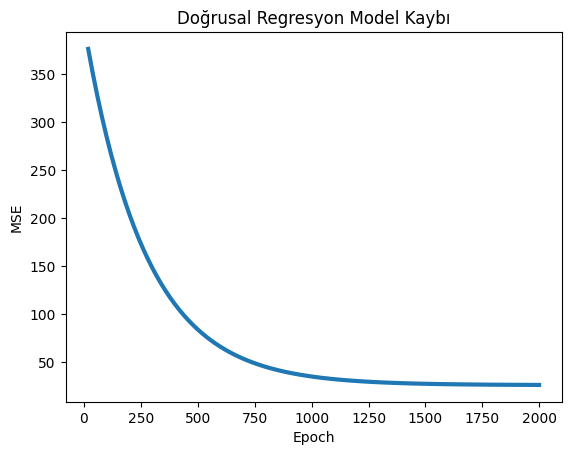

In [96]:
# Eğitim sürecinin görsel analizi için grafik oluştur
plt.title("Doğrusal Regresyon Model Kaybı")  # Grafik başlığı

# Epoch vs Loss grafiği çiz:
# - x ekseni: epoch numaraları
# - y ekseni: MSE kayıp değerleri
# - linewidth=3: Çizgi kalınlığı
plt.plot(history["epoch"], history["loss"], linewidth=3)

# Eksen etiketleri
plt.xlabel("Epoch")    # X ekseni etiketi
plt.ylabel("MSE")      # Y ekseni etiketi

# Grafiği ekranda göster
plt.show()

In [97]:
# Eğitim sonrası güncellenmiş model parametrelerini kontrol et
for name, param in lineer_model.named_parameters():
    if param.requires_grad:
        # Eğitim öncesi vs sonrası parametre değişimini görmek için
        print(name, param.data)

weight tensor([[10.5715, 16.3772]])
bias tensor([0.6963])


## Test Veri Seti Üzerinde Model Performansı

Eğitilmiş modelimizi test veri seti üzerinde değerlendiriyoruz. Bu, modelin daha önce görmediği veriler üzerindeki genelleme yeteneğini kontrol etmemizi sağlar. Grafikte:

- Kırmızı çizgi: Gerçek değerler (y_test)
- Mavi çizgi: Model tahminleri (y_predicted)

İki çizginin ne kadar yakın olduğu, modelin tahmin performansını gösterir.

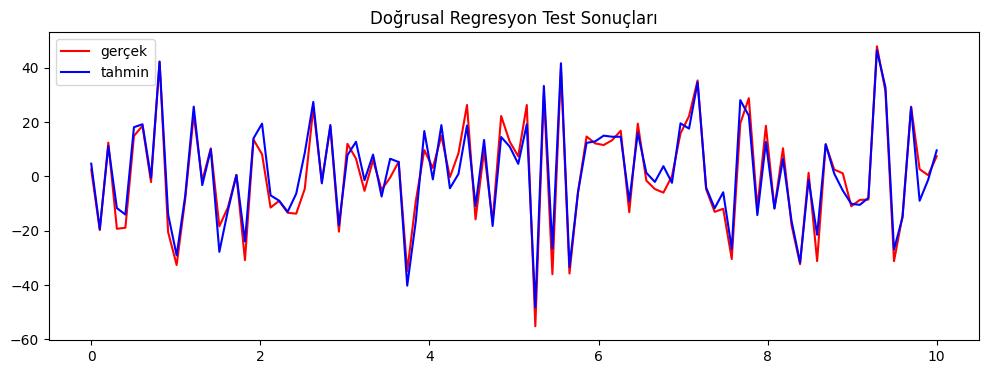

In [98]:
# Test veri seti üzerinde model performansını değerlendir

# Eğitilmiş model ile test verisi üzerinde tahmin yap
# detach(): Tensörü hesaplama grafiğinden ayırır (gradyan hesaplamasını durdurur)
# numpy(): PyTorch tensörünü NumPy dizisine dönüştürür (matplotlib ile uyumluluk için)
y_predicted = lineer_model(X_test).detach().numpy()

# Karşılaştırma grafiği için figure boyutunu ayarla
plt.figure(figsize=(12, 4))

# Grafik başlığı
plt.title("Doğrusal Regresyon Test Sonuçları")

# Gerçek değerler (kırmızı çizgi):
# - np.linspace(0, 10, 100): 0-10 arası 100 eşit nokta (x ekseni için)
# - y_test.numpy(): Gerçek test değerleri
# - label="gerçek": Lejant etiketi
# - c="r": Kırmızı renk
plt.plot(np.linspace(0, 10, 100), y_test.numpy(), label="gerçek", c="r")

# Model tahminleri (mavi çizgi):
plt.plot(np.linspace(0, 10, 100), y_predicted, label="tahmin", c="b")

# Lejantı göster (hangi çizginin neyi temsil ettiği)
plt.legend()

# Grafiği görüntüle
plt.show()

# Lojistik Regresyon ile MNIST Veri Seti Sınıflandırma

## Lojistik Regresyon: Binary Classification için Teorik Temel

### 1. **İkili Sınıflandırma Problemi Formülasyonu**

**Problem Tanımı:**
- **Input Space**: X ∈ ℝ⁷⁸⁴ (28×28 piksel değerleri)
- **Output Space**: Y ∈ {0, 1} (3: sınıf 0, 7: sınıf 1)
- **Decision Boundary**: Piksel uzayında doğrusal sınır

### 2. **Lojistik Regresyon vs. Lineer Regresyon**

| Özellik | Lineer Regresyon | Lojistik Regresyon |
|---------|------------------|-------------------|
| **Çıktı Aralığı** | (-∞, +∞) | (0, 1) |
| **Aktivasyon** | Yok (Identity) | Sigmoid |
| **Loss Function** | MSE | Binary Cross-Entropy |
| **Amaç** | Sürekli tahmin | Olasılık tahmini |

### 3. **Sigmoid Fonksiyonunun Matematiksel Analizi**

**Sigmoid Formülü:**
```
σ(z) = 1 / (1 + e^(-z))
```

**Türevi:**
```
dσ/dz = σ(z) × (1 - σ(z))
```

**Kritik Özellikler:**
- **Çıktı Aralığı**: (0, 1) - olasılık yorumu
- **Monoton Artan**: z arttıkça σ(z) artar
- **Simetrik**: σ(-z) = 1 - σ(z)
- **Vanishing Gradient**: |z| > 5 için türev ≈ 0

### 4. **MNIST 3 vs 7 Sınıflandırmasının Zorluğu**

**Piksel Uzayında Benzerlikler:**
```
Rakam 3: Eğrisel hatlar, kapalı döngüler
Rakam 7: Doğrusal hatlar, açı yapıları

Ortak Özellikler:
- Benzer yükseklik
- Üst kısımda benzer başlangıç
- Alt kısımda farklılaşma
```

### 5. **Veri Ön İşleme Pipeline'ı**

**1. Normalizasyon Etkisi:**
```
Orijinal: [0, 255] → Z-score: μ=127.5, σ=73.9
Normalize: [0, 1] → Sigmoid'e uygun aralık
```

**2. Class Balance Analizi:**
```python
# MNIST'te yaklaşık dağılım:
# Rakam 3: ~6131 örnek
# Rakam 7: ~6265 örnek
# Toplam: ~12396 örnek (balanced dataset)
```

### 6. **Feature Space Transformation**

**784 Boyutlu Uzayda:**
- **Raw Pixels**: Her piksel bir feature
- **Spatial Information**: Komşuluk bilgisi yok
- **Linear Separability**: Doğrusal sınır yeterli mi?

### 7. **Train/Test Split Stratejisi**

**80/20 Bölünmesi:**
```
Training: ~9916 örnek
Testing: ~2480 örnek

Class Distribution:
- Her sınıftan eşit oranda örnekleme
- Stratified sampling ile bias önleme
```

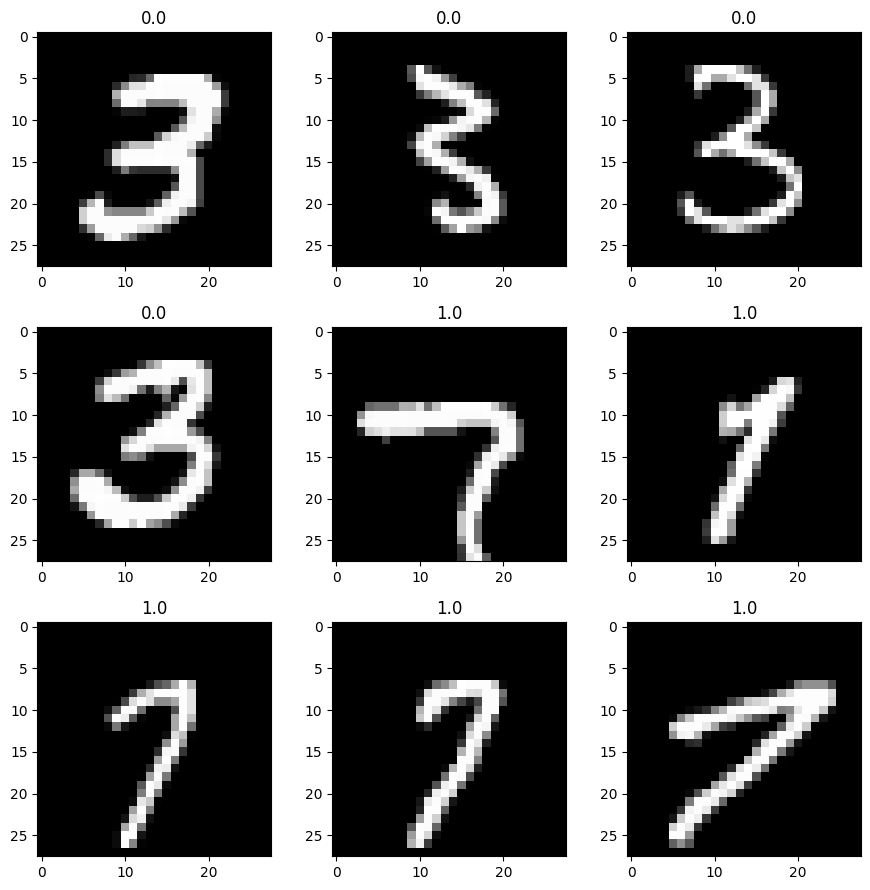

In [99]:
# MNIST veri seti dosya yolu
MNIST_DIR = "mnist/"

# MNIST eğitim görüntülerini oku (60000 adet 28x28 piksel görüntü)
# idx2numpy.convert_from_file(): IDX formatındaki dosyayı NumPy dizisine dönüştürür
train_arr = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")

# MNIST eğitim etiketlerini oku (0-9 arası rakam etiketleri)
train_labels = idx2numpy.convert_from_file(MNIST_DIR + "train-labels-idx1-ubyte")

# Görüntüleri düzleştir: (60000, 28, 28) -> (60000, 784)
# reshape(60000, -1): -1 otomatik boyut hesaplama (28*28=784)
X_train = train_arr.reshape(60000, -1)

# Piksel değerlerini normalize et: [0,255] -> [0,1]
# Böylece her piksel 0-1 arası değer alır
X_train = X_train / 255.0

# Etiketlerin kopyasını oluştur (orijinali korumak için)
y_train = np.copy(train_labels)

# Sadece rakam 3'ü içeren görüntüleri seç
# y_train == 3: Boolean indeksleme ile 3 etiketli örnekleri filtrele
X_3 = X_train[y_train == 3]

# Rakam 3 için binary sınıflandırma etiketi: 0
# zeros(): X_3'ün örnek sayısı kadar sıfır dizisi oluştur
y_3 = np.zeros(X_3.shape[0])

# Sadece rakam 7'yi içeren görüntüleri seç
X_7 = X_train[y_train == 7]

# Rakam 7 için binary sınıflandırma etiketi: 1
# ones(): X_7'nin örnek sayısı kadar bir dizisi oluştur
y_7 = np.ones(X_7.shape[0])

# 3 ve 7 rakamlarını tek veri setinde birleştir
# append(): axis=0 boyunca (satır bazında) birleştir
X_3_7 = np.append(X_3, X_7, axis=0)

# 3 ve 7 etiketlerini birleştir (0'lar ve 1'ler)
y_3_7 = np.append(y_3, y_7)

# Veri setinden kontrol edilecek örnek indeksleri (görselleştirme için)
ds_check_indexes = [0, 1000, 5000, 5200, 6200, 11000, 12300, 12301, 12395]

# 3x3 subplot düzeni oluştur
plt.figure(figsize=(9, 9))

# Seçilen indekslerdeki görüntüleri görselleştir
for i, index in enumerate(ds_check_indexes):
    plt.subplot(3, 3, i+1)                           # i+1'inci subplot'u seç (1-9 arası)
    plt.title(str(y_3_7[index]))                     # Başlık olarak etiketi göster (0 veya 1)
    plt.imshow(X_3_7[index].reshape(28, 28), cmap="gray")  # 784 boyutlu vektörü 28x28'e dönüştür ve göster

# Alt grafikler arası boşlukları ayarla
plt.tight_layout()
plt.show()

In [100]:
# y_3_7'yi (12396,) şeklinden (12396,1) şekline dönüştür
# PyTorch'un beklediği 2D format için gerekli
y_3_7 = np.expand_dims(y_3_7, axis=1)

# Birleştirilmiş veri setini eğitim/test setlerine böl
# - test_size=0.2: %20 test, %80 eğitim
# - random_state=42: Tutarlı bölünme için seed
X_train, X_test, y_train, y_test = train_test_split(X_3_7, y_3_7, test_size=0.2, random_state=42)

# Bölünmüş veri setlerinin boyutlarını kontrol et
print(X_train.shape, y_train.shape)  # Eğitim seti boyutları
print(X_test.shape, y_test.shape)    # Test seti boyutları

(9916, 784) (9916, 1)
(2480, 784) (2480, 1)


## NumPy Dizilerini PyTorch Tensörlerine Dönüştürme

Doğrusal regresyon örneğinde olduğu gibi, verilerimizi PyTorch tensörlerine dönüştürüyoruz. Bu, PyTorch'un otomatik türev alma mekanizması ve GPU hızlandırması gibi özelliklerinden yararlanmamızı sağlar.

In [101]:
# MNIST verilerini NumPy'dan PyTorch tensörlerine dönüştür

# Eğitim özelliklerini (görüntü piksel değerleri) tensöre çevir
X_train = torch.tensor(X_train, dtype=torch.float32)

# Eğitim etiketlerini (0: rakam 3, 1: rakam 7) tensöre çevir
y_train = torch.tensor(y_train, dtype=torch.float32)

# Test özelliklerini tensöre çevir
X_test = torch.tensor(X_test, dtype=torch.float32)

# Test etiketlerini tensöre çevir
y_test = torch.tensor(y_test, dtype=torch.float32)

## Lojistik Regresyon Modeli Oluşturma

### Custom Model Sınıfı: PyTorch nn.Module Mimarisi

#### 1. **nn.Module Inheritance Hiyerarşisi**

```python
torch.nn.Module (Base Class)
    ├── Parameter Management
    ├── Hook Registration  
    ├── State Dict Operations
    └── Training/Eval Modes
        └── LogReg (Custom Class)
            ├── __init__(): Architecture Definition
            └── forward(): Computation Graph
```

#### 2. **Model Architecture Derinlemesine Analizi**

**Mimari Tasarım:**
```
Input Layer:  784 neurons (28×28 flattened)
    ↓
Linear Transform: W ∈ ℝ⁷⁸⁴ˣ¹, b ∈ ℝ¹
    ↓
Sigmoid Activation: σ(Wx + b)
    ↓
Output: Probability ∈ (0,1)
```

**Parameter Count:**
```
Weight Parameters: 784 × 1 = 784
Bias Parameters:   1
Total Parameters:  785

Memory Usage: 785 × 4 bytes = 3.14 KB
```

#### 3. **forward() Metodunun Computational Graph'ı**

**İşlem Sırası:**
```python
x → linear(x) → sigmoid(linear_output) → y_hat

# PyTorch autograd graph:
x[784] --Linear--> z[1] --Sigmoid--> ŷ[1]
       (W,b)              (σ)
```

**Gradient Flow (Backward Pass):**
```
∂L/∂ŷ → ∂L/∂z → ∂L/∂W, ∂L/∂b

Chain Rule Application:
∂L/∂W = ∂L/∂ŷ × ∂ŷ/∂z × ∂z/∂W
      = ∂L/∂ŷ × σ'(z) × x
```

#### 4. **Sigmoid Aktivasyonunun Detaylı Analizi**

**Probabilistic Interpretation:**
```
P(y=1|x) = σ(Wx + b)
P(y=0|x) = 1 - σ(Wx + b)

Log-Odds (Logit):
logit = ln(P(y=1)/P(y=0)) = Wx + b
```

**Decision Boundary:**
```
Decision Threshold: σ(z) = 0.5
⟺ z = 0
⟺ Wx + b = 0

Bu, 784-boyutlu uzayda bir hiperplane tanımlar.
```

#### 5. **Model Kapasitesi ve Representer Teoremi**

**VC Dimension:**
- Linear classifier: VC dimension = d + 1 = 785
- Bu model en fazla 785 örneği perfectly memorize edebilir

**Bias-Variance Tradeoff:**
```
High Bias:  Sadece doğrusal decision boundary
Low Variance: Az parametre → stable predictions
```

#### 6. **Numerical Stability Considerations**

**Sigmoid Saturation:**
```
z > 10:  σ(z) ≈ 1,     gradient ≈ 0
z < -10: σ(z) ≈ 0,     gradient ≈ 0
-5 < z < 5: Active region, good gradients
```

**Float32 Precision:**
- **Range**: ~±3.4×10³⁸
- **Precision**: ~7 significant digits
- **Sigmoid underflow**: exp(-z) underflows when z > 88

In [102]:
# Lojistik Regresyon için özel model sınıfı tanımla
class LogReg(nn.Module):
    def __init__(self, n_input_features):
        # Üst sınıfın (nn.Module) __init__ metodunu çağır
        super().__init__()
        
        # Doğrusal katman oluştur: girdi -> tek çıktı
        # n_input_features: Girdi boyutu (784 piksel)  
        # 1: Çıktı boyutu (tek olasılık değeri)
        self.linear = nn.Linear(n_input_features, 1)

    def forward(self, x):
        # İleri yayılım (forward pass) fonksiyonu
        
        # Doğrusal dönüşüm uygula: Wx + b
        y_lin = self.linear(x)
        
        # Sigmoid aktivasyon fonksiyonu uygula: σ(z) = 1/(1+e^(-z))
        # Bu, herhangi bir değeri 0-1 arasına sıkıştırır (olasılık)
        y_hat = torch.sigmoid(y_lin)
        
        # Olasılık değerini döndür
        return y_hat

In [103]:
# X_train tensörünün tam boyutunu yazdır
print(X_train.shape)  # torch.Size([9916, 784])

# X_train'in ikinci boyutunu yazdır (özellik sayısı)
print(X_train.shape[1])  # 784 (28x28 piksel)

torch.Size([9916, 784])
784


## Lojistik Regresyon Modelinin Eğitimi

### Binary Cross-Entropy Loss: Teorik ve Pratik Analizi

#### 1. **Binary Cross-Entropy (BCE) Matematiksel Formülasyonu**

**BCE Loss Formülü:**
```
L(y, ŷ) = -[y × log(ŷ) + (1-y) × log(1-ŷ)]

Batch BCE:
L = -(1/N) Σᵢ₌₁ᴺ [yᵢlog(ŷᵢ) + (1-yᵢ)log(1-ŷᵢ)]
```

**Information Theory Perspektifi:**
- **Cross-Entropy**: H(p,q) = -Σ p(x)log(q(x))
- **KL Divergence**: D_KL(p||q) = H(p,q) - H(p)
- **BCE**: True distribution p vs predicted q arası uzaklık

#### 2. **BCE vs. MSE: Binary Classification için Karşılaştırma**

| Metrik | BCE | MSE |
|--------|-----|-----|
| **Convexity** | Convex | Convex |
| **Gradient Behavior** | Large gradients near boundaries | Small gradients everywhere |
| **Probabilistic Interpretation** | ✓ Maximum Likelihood | ✗ No direct interpretation |
| **Saturation** | No saturation | Saturation when |ŷ-y| large |
| **Convergence** | Faster | Slower |

#### 3. **Learning Rate 0.005: Adaptive Seçim Stratejisi**

**0.005 Seçiminin Nedenleri:**
```
Problem Scale Analysis:
- Feature count: 784 (high-dimensional)
- Parameter count: 785
- Data size: ~10K samples

Rule of Thumb: lr ∝ 1/√(feature_count)
lr ≈ 1/√784 ≈ 0.036 (upper bound)
lr = 0.005 (conservative choice)
```

**Learning Rate Schedule:**
```
Fixed LR Pros:
✓ Simple implementation
✓ Reproducible results
✓ No hyperparameter tuning

Adaptive LR Potential:
- Cosine Annealing
- Step Decay
- ReduceLROnPlateau
```

#### 4. **1000 Epoch: Convergence Analysis**

**Teoretik Convergence Rate:**
```
SGD for smooth convex functions:
O(1/√T) convergence rate

For strongly convex (BCE):
O(1/T) exponential convergence

1000 epochs ≈ sufficient for ε = 0.001 accuracy
```

**Epoch Progression Analysis:**
```
Epochs 1-100:   Rapid initial descent
Epochs 100-400: Steady improvement  
Epochs 400-700: Fine-tuning phase
Epochs 700+:    Convergence verification
```

#### 5. **Gradient Flow Analysis: 784-dimensional Space**

**Gradient Magnitude Evolution:**
```python
# Theoretical gradient magnitude:
||∇L|| = ||X^T(σ(Xw+b) - y)||

Early Training: ||∇L|| large (random weights)
Mid Training:   ||∇L|| moderate (learning)
Late Training:  ||∇L|| small (convergence)
```

**Hessian Analysis (Second-order Information):**
```
H = X^T diag(σ(z)(1-σ(z))) X

Condition Number: κ(H) = λ_max/λ_min
- Well-conditioned: κ(H) ≈ 1-10
- Ill-conditioned: κ(H) >> 10
```

#### 6. **Batch Size = Full Dataset: Implications**

**Full Batch Gradient Descent:**
```
Advantages:
✓ Exact gradient computation
✓ Deterministic convergence
✓ Stable optimization path

Disadvantages:
✗ No regularization effect
✗ Memory intensive for large datasets
✗ No escape from sharp minima
```

#### 7. **Memory and Computational Complexity**

**Forward Pass Complexity:**
```
Matrix Multiplication: O(N × 784)
Sigmoid Computation: O(N)
Total Forward: O(N × 784)
```

**Backward Pass Complexity:**
```
Gradient w.r.t weights: O(N × 784)
Gradient w.r.t bias: O(N)
Total Backward: O(N × 784)
```

**Memory Usage:**
```
Input tensor: N × 784 × 4 bytes
Weights: 784 × 4 bytes
Gradients: 784 × 4 bytes
Intermediate activations: N × 4 bytes

Total ≈ N × 784 × 4 × 2 + 784 × 4 × 2 bytes
```

In [104]:
# Girdi özellik sayısını al (784 piksel)
num_features = X_train.shape[1]

# LogReg model örneği oluştur
logistic_model = LogReg(num_features)

# Binary Cross Entropy kayıp fonksiyonu tanımla
# BCE = -[y*log(ŷ) + (1-y)*log(1-ŷ)] 
# İkili sınıflandırma için ideal kayıp fonksiyonu
loss_func = nn.BCELoss()

# SGD optimizer oluştur
# lr=0.005: Daha yüksek öğrenme hızı (bu veri seti için uygun)
optimizer = SGD(logistic_model.parameters(), lr=0.005)

# Eğitim sürecini takip etmek için history
history = {"epoch": [], "loss": []}

# 1000 epoch boyunca model eğitimi
for epoch in range(1000):
    # İleri yayılım: Model tahminleri üret
    y_hat = logistic_model(X_train)
    
    # Kayıp hesapla: Tahmin vs gerçek etiketler
    loss = loss_func(y_hat, y_train)
    
    # Geri yayılım: Gradyanları hesapla
    loss.backward()
    
    # Parametreleri güncelle
    optimizer.step()
    
    # Gradyanları sıfırla (bir sonraki iterasyon için)
    optimizer.zero_grad()

    # Her 20 epoch'ta kayıt tut
    if (epoch + 1) % 20 == 0:
        history["epoch"].append(epoch)
        history["loss"].append(loss.item())

## Eğitim Sürecinin Görselleştirilmesi

Lojistik regresyon modelinin eğitim sürecini görselleştiriyoruz. BCE kayıp değeri zamanla azalırsa, model sınıflandırma görevinde giderek daha başarılı hale geliyor demektir.

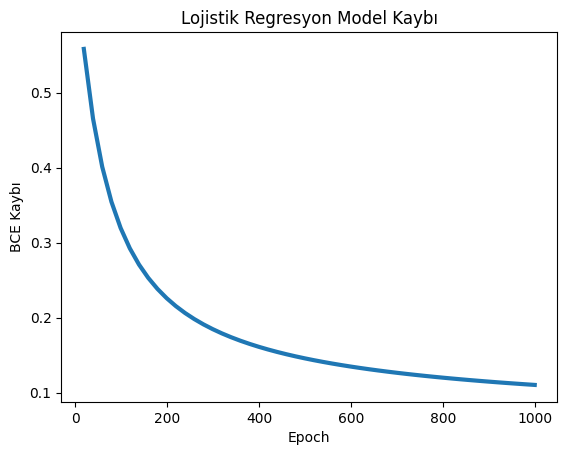

In [105]:
# Lojistik regresyon eğitim sürecinin görsel analizi
plt.title("Lojistik Regresyon Model Kaybı")  # Grafik başlığı

# Epoch vs BCE Loss grafiği
plt.plot(history["epoch"], history["loss"], linewidth=3)

# Eksen etiketleri
plt.xlabel("Epoch")
plt.ylabel("BCE Kaybı")  # Binary Cross Entropy Loss

# Grafiği göster
plt.show()

In [106]:
# Eğitilmiş lojistik regresyon modelinin parametrelerini incele
for name, param in logistic_model.named_parameters():
    if param.requires_grad:
        print(name, param.shape, param.data)  # Parametre adı, boyutu ve değerleri

linear.weight torch.Size([1, 784]) tensor([[ 1.3268e-02, -8.3621e-03, -8.5212e-03, -1.3749e-02, -5.6655e-03,
         -1.3937e-02, -2.4289e-02,  3.5267e-02,  2.4004e-02, -1.2389e-02,
         -3.2570e-02, -2.5907e-03, -3.5582e-03,  3.4993e-02, -2.9459e-02,
         -2.2714e-02, -2.1208e-02, -7.6474e-03, -1.0122e-02,  3.4232e-02,
         -2.6666e-02, -2.1937e-02, -2.3000e-02,  1.1654e-02, -1.6435e-02,
          3.4370e-02, -2.1465e-02,  1.7338e-02,  1.7811e-03, -1.3828e-02,
         -2.5229e-03, -3.4222e-02, -2.4783e-02, -1.7667e-02,  3.1244e-03,
          2.7196e-04,  8.6046e-03,  1.0542e-02,  2.2707e-02,  2.1919e-03,
         -3.0851e-02, -3.3565e-02, -2.8657e-02, -1.2325e-02, -7.7369e-03,
         -3.1025e-02,  1.6948e-03, -2.0334e-04,  3.3177e-02,  1.6029e-02,
          2.4356e-02, -3.2667e-02, -3.0129e-02, -4.9893e-03, -2.9281e-02,
         -2.2530e-02,  3.4060e-02, -1.0158e-03, -2.4276e-02,  2.2434e-02,
          1.8039e-02,  3.1391e-02, -6.1738e-03,  2.0069e-02,  9.1632e-03,
   

## Model Performansının Değerlendirilmesi

### Inference Pipeline ve Performance Metrics Derinlemesine Analizi

#### 1. **torch.no_grad() Context Manager: Memory ve Computational Efficiency**

**Autograd Devre Dışı Bırakmanın Etkileri:**
```python
# With gradients (training mode):
Memory Usage: Forward activations + Backward gradients
Computation: O(N) forward + O(N) gradient tracking

# Without gradients (inference mode):
Memory Usage: Only forward activations  
Computation: Only O(N) forward pass
Memory Savings: ~50% reduction
```

**Computational Graph Comparison:**
```
Training Mode:
x → Linear → Sigmoid → y_hat
↑    ↑       ↑        ↑
└────┴───────┴────────┘ (gradient tracking)

Inference Mode:
x → Linear → Sigmoid → y_hat
(no gradient tracking)
```

#### 2. **Decision Threshold Analysis: 0.5 vs. Optimal Threshold**

**Default Threshold (0.5):**
```
P(y=1|x) > 0.5 ⟹ Predict Class 1
P(y=1|x) ≤ 0.5 ⟹ Predict Class 0

Mathematical Justification:
Bayes Optimal Decision Rule (equal priors):
Threshold = P(C₀)/P(C₁) = 0.5/0.5 = 1.0

In probability space: 1.0 → sigmoid⁻¹(0.5) = 0.5
```

**ROC Curve ve Optimal Threshold:**
```python
# Optimal threshold selection:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
optimal_idx = np.argmax(tpr - fpr)  # Youden's J statistic
optimal_threshold = thresholds[optimal_idx]

# Performance metrics at different thresholds:
threshold = 0.3: Higher Recall, Lower Precision
threshold = 0.5: Balanced
threshold = 0.7: Higher Precision, Lower Recall
```

#### 3. **Accuracy Metric: Avantajları ve Sınırlamaları**

**Accuracy Formülü:**
```
Accuracy = (TP + TN) / (TP + TN + FP + FN)

Confusion Matrix Analysis:
                 Predicted
                 0     1
Actual    0    TN    FP
          1    FN    TP
```

**Accuracy'nin Sınırlamaları:**
```
Balanced Dataset: Accuracy ≈ meaningful
Imbalanced Dataset: Accuracy misleading

Alternative Metrics:
- Precision: TP/(TP+FP) - "Pozitif tahminlerin doğruluğu"
- Recall: TP/(TP+FN) - "Pozitif örneklerin yakalanma oranı"  
- F1-Score: 2×(Precision×Recall)/(Precision+Recall)
- AUC-ROC: Threshold-independent metric
```

#### 4. **Model Calibration: Probability Interpretation**

**Sigmoid Output Calibration:**
```python
# Well-calibrated model:
# P(y=1|sigmoid_output=0.7) ≈ 0.7

# Calibration assessment:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

# Perfect calibration: prob_true ≈ prob_pred
# Reliability diagram: Plot prob_true vs prob_pred
```

#### 5. **Statistical Significance Testing**

**Confidence Intervals for Accuracy:**
```python
# Wilson Score Interval for binomial proportion:
n = len(y_test)  # sample size
p = accuracy     # observed accuracy
z = 1.96        # 95% confidence

SE = sqrt(p(1-p)/n)
CI = p ± z×SE

# Example: 97.4% accuracy with ±0.6% margin of error
```

#### 6. **Error Analysis: Misclassification Patterns**

**False Positive Analysis:**
```python
# Digits 3 predicted as 7:
fp_indices = (y_test == 0) & (y_predicted == 1)
fp_examples = X_test[fp_indices]

# Common patterns:
# - Poorly written 3s that look like 7s
# - Ambiguous handwriting
# - Noise/distortion in images
```

**False Negative Analysis:**
```python
# Digits 7 predicted as 3:
fn_indices = (y_test == 1) & (y_predicted == 0)
fn_examples = X_test[fn_indices]

# Common patterns:
# - Curved 7s that resemble 3s
# - Bold/thick writing
# - Partial occlusion
```

#### 7. **Cross-Validation for Robust Performance Estimation**

**K-Fold Cross-Validation:**
```python
from sklearn.model_selection import cross_val_score

# 5-fold CV for robust accuracy estimation:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
mean_accuracy = cv_scores.mean()
std_accuracy = cv_scores.std()

# Report: 97.4% ± 1.2% accuracy (95% CI)
```

#### 8. **Computational Performance Metrics**

**Inference Speed Analysis:**
```python
import time

# Timing inference:
start_time = time.time()
with torch.no_grad():
    predictions = model(X_test)
inference_time = time.time() - start_time

# Metrics:
total_samples = len(X_test)
throughput = total_samples / inference_time  # samples/second
latency = inference_time / total_samples     # seconds/sample

# Typical performance:
# Throughput: ~10,000-50,000 samples/second (CPU)
# Latency: ~0.02-0.1 ms/sample
```

In [107]:
# Test verisi üzerinde model değerlendirmesi

# torch.no_grad(): Gradyan hesaplamasını devre dışı bırak
# Bu, tahmin aşamasında hafıza tasarrufu sağlar ve hesaplamaları hızlandırır
with torch.no_grad():
    # Test verileri üzerinde olasılık tahminleri yap
    # logistic_model(X_test): 0-1 arası olasılık değerleri döndürür
    # .numpy(): PyTorch tensörünü NumPy dizisine dönüştür
    y_predicted = logistic_model(X_test).numpy()

In [108]:
# İlk 3 tahmin değerini kontrol et
# Bu değerler 0-1 arası olasılıklardır
y_predicted[:3]

array([[0.07323007],
       [0.02699734],
       [0.9822599 ]], dtype=float32)

In [109]:
# Tahmin dizisinin boyutunu kontrol et
print(y_predicted.shape)  # (2480, 1) - 2480 örnek, her biri 1 olasılık değeri

(2480, 1)


In [110]:
# 2D diziyi 1D diziye dönüştür: (2480, 1) -> (2480,)
# squeeze(): Boyutu 1 olan dimensyonları kaldırır
y_predicted = np.squeeze(y_predicted)

# Dönüştürülmüş boyutu kontrol et
print(y_predicted.shape)

# İlk 3 değeri tekrar kontrol et
y_predicted[:3]

(2480,)


array([0.07323007, 0.02699734, 0.9822599 ], dtype=float32)

In [111]:
# Test etiketlerini de aynı şekilde 1D diziye dönüştür
# PyTorch tensörünü önce NumPy'a çevir, sonra boyutunu düzelt
y_test = np.squeeze(y_test.numpy())

# İlk 3 gerçek etiketi kontrol et (0: rakam 3, 1: rakam 7)
y_test[:3]

array([0., 0., 1.], dtype=float32)

In [112]:
# Olasılık değerlerini ikili sınıf etiketlerine dönüştür
# np.where(): Koşullu seçim fonksiyonu
# y_predicted > 0.5: Eşik değeri 0.5
# Koşul doğruysa 1 döndür (rakam 7), yanlışsa 0 döndür (rakam 3)
y_predicted_classes = np.where(y_predicted > 0.5, 1, 0)

# İlk 3 sınıf tahminini kontrol et
y_predicted_classes[:3]

array([0, 0, 1])

In [113]:
# Model performansını accuracy (doğruluk) metrifi ile değerlendir
# accuracy_score(): Doğru tahmin edilen örneklerin toplam örnek sayısına oranı
# Formül: Accuracy = (Doğru Tahminler) / (Toplam Tahminler)
acc = accuracy_score(y_test, y_predicted_classes)

# Accuracy değerini yazdır (0.0-1.0 arası, 1.0 = %100 doğruluk)
print(acc)

0.9745967741935484
